# 🔥 Modelo A — Predicción de Falla Térmica Inminente
## SSA-LSTM: Predicción de sobrecalentamiento >85°C en 30-60 minutos

**Flota**: 60 camiones CAT 797F — Minera Las Bambas  
**Objetivo**: Clasificación binaria — ¿Superará el neumático los 85°C en los próximos 30-60 min?  
**Arquitectura**: LSTM 2 capas (64→32 unidades) + Dropout(0.2) + Sigmoid  
**Ventana temporal**: 60 registros (= 60 minutos a 1 reg/min)  

---

## 1. Instalación y Configuración

In [1]:
# Instalar dependencias si es necesario
import subprocess, sys
packages = ['tensorflow', 'scikit-learn', 'pandas', 'numpy', 'matplotlib', 'seaborn', 'joblib']
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + packages)
print('Dependencias OK')

Dependencias OK


In [2]:
import tensorflow as tf

print("TensorFlow:", tf.__version__)
print("GPU disponible:", tf.config.list_physical_devices('GPU'))

2026-05-22 12:09:57.119286: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779469797.129857 1448068 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779469797.133367 1448068 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-22 12:09:57.144599: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow: 2.18.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, f1_score, precision_score, recall_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

# Configuración reproducibilidad
np.random.seed(42)
tf.random.set_seed(42)

# Rutas
DATA_PATH = Path('../EDA/telemetria_bambas_2026_enero.csv')
MODEL_DIR = Path('./artifacts/modelo_A')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 1}')
print(f'Directorio de modelo: {MODEL_DIR}')

TensorFlow: 2.18.0
GPU disponible: True
Directorio de modelo: artifacts/modelo_A


## 2. Carga y Exploración de Datos

In [4]:
# Cargar dataset
print('Cargando dataset...')
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
df = df.sort_values(['id_camion', 'id_neumatico', 'timestamp']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'\nColumnas: {list(df.columns)}')
print(f'\nRango de fechas: {df.timestamp.min()} → {df.timestamp.max()}')
print(f'Camiones únicos: {df.id_camion.nunique()}')
print(f'Neumáticos únicos: {df.id_neumatico.nunique()}')
df.head(3)

Cargando dataset...
Shape: (259560, 22)

Columnas: ['timestamp', 'id_camion', 'id_neumatico', 'posicion', 'tajo_asignado', 'estado_operativo', 'latitud', 'longitud', 'condiciones', 'distancia_chancadora_km', 'payload_ton', 'velocidad_kmh', 'presion_psi', 'temperatura_c', 'vibracion_g', 'tkph_real', 'profundidad_inicial_mm', 'profundidad_actual_mm', 'desgaste_mm_h', 'horas_trabajadas_acumuladas', 'vida_util_proyectada_horas', 'cph_actual']

Rango de fechas: 2026-01-01 00:00:00 → 2026-01-31 00:00:00
Camiones únicos: 60
Neumáticos únicos: 360


,timestamp,id_camion,id_neumatico,posicion,tajo_asignado,estado_operativo,latitud,longitud,condiciones,distancia_chancadora_km,...,presion_psi,temperatura_c,vibracion_g,tkph_real,profundidad_inicial_mm,profundidad_actual_mm,desgaste_mm_h,horas_trabajadas_acumuladas,vida_util_proyectada_horas,cph_actual
0,2026-01-01 00:00:00,CAT_001,N5980-CAT_001-P1,1,Tajo_1 (Tajo Norte),Operando,-14.084418,-72.280544,"Roca 70 MPa, +10% pendiente, sube cargado",4.5,...,112.5,70.9,0.82,6542.8,65.0,64.99,0.00561,1,6201.0,8.39
1,2026-01-01 01:00:00,CAT_001,N5980-CAT_001-P1,1,Tajo_1 (Tajo Norte),Operando,-14.086252,-72.283047,"Roca 70 MPa, +10% pendiente, sube cargado",4.5,...,108.9,65.5,0.86,4560.8,65.0,64.99,0.00769,2,6201.0,8.39
2,2026-01-01 02:00:00,CAT_001,N5980-CAT_001-P1,1,Tajo_1 (Tajo Norte),Operando,-14.086271,-72.283011,"Roca 70 MPa, +10% pendiente, sube cargado",4.5,...,110.4,68.0,1.11,5261.4,65.0,64.98,0.00650,3,6201.0,8.39


In [5]:
print('Estadísticas clave:')
cols_stats = ['temperatura_c', 'presion_psi', 'velocidad_kmh', 'payload_ton', 'tkph_real', 'vibracion_g']
df[cols_stats].describe().round(2)

Estadísticas clave:


,temperatura_c,presion_psi,velocidad_kmh,payload_ton,tkph_real,vibracion_g
count,259560.00,259560.00,259560.00,259560.00,259560.00,259560.00
mean,69.74,110.55,22.52,271.98,3603.13,1.59
std,22.97,3.97,10.44,115.13,1680.90,0.97
min,16.80,100.00,0.00,0.00,0.00,-0.15
25%,62.10,107.30,20.80,302.10,3294.60,0.98
50%,66.20,110.40,25.60,316.70,4081.30,1.44
75%,90.30,113.80,29.20,328.20,4672.60,2.36
max,111.80,123.80,48.10,390.70,7734.70,5.18


## 3. Feature Engineering y Construcción del Target

In [6]:
# === Feature Engineering ===
# Encoding tajo
df['tajo_enc'] = (df['tajo_asignado'] == 'Tajo Sur').astype(int)

# Features de secuencia temporal
FEATURE_COLS = ['temperatura_c', 'velocidad_kmh', 'payload_ton', 
                'presion_psi', 'tkph_real', 'vibracion_g', 'tajo_enc']

# === Construcción del TARGET ===
# Target: ¿la temperatura_c superará 85°C en los próximos 30-60 registros?
WINDOW_FUTURE = 60   # 60 minutos hacia adelante
TEMP_THRESHOLD = 85.0

print('Construyendo target: max_temp_futura...')

df['max_temp_futura'] = (
    df.groupby(['id_camion', 'id_neumatico'])['temperatura_c']
    .transform(lambda x: x.shift(-1).rolling(window=WINDOW_FUTURE, min_periods=1).max())
)

df['target_termal'] = (df['max_temp_futura'] > TEMP_THRESHOLD).astype(int)

# Eliminar NaN al final de cada secuencia
df = df.dropna(subset=['max_temp_futura']).reset_index(drop=True)

print(f'Distribución target:')
print(df['target_termal'].value_counts(normalize=True).round(3))
print(f'\nRegistros totales: {len(df):,}')

Construyendo target: max_temp_futura...
Distribución target:
target_termal
0    0.5
1    0.5
Name: proportion, dtype: float64

Registros totales: 259,560


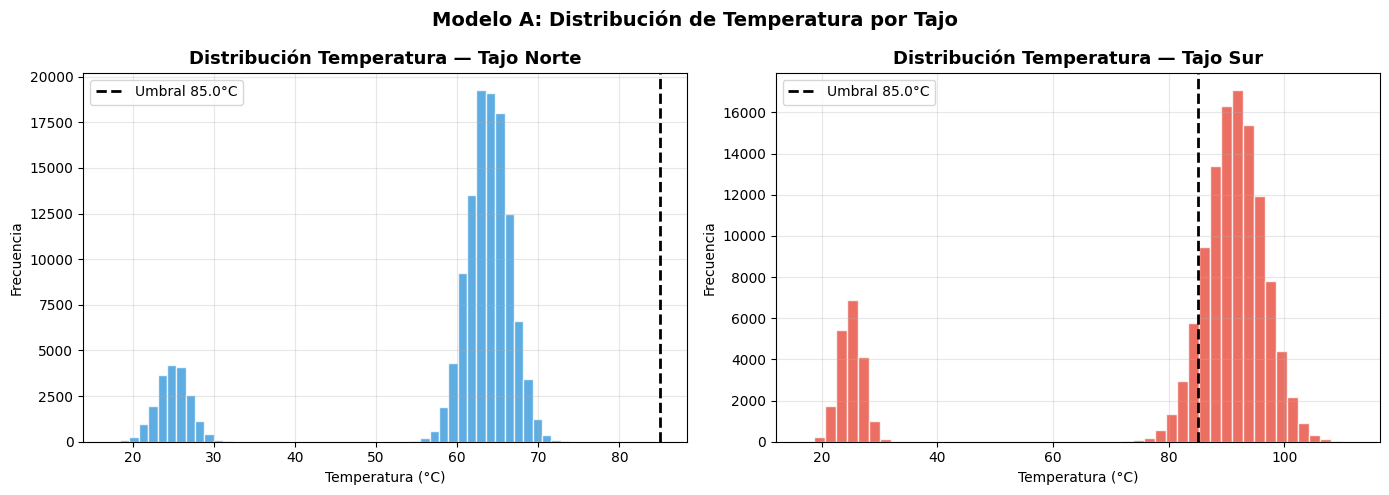

✅ Plot guardado


In [7]:
# Visualización distribución de temperatura por tajo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, tajo in zip(axes, ['Tajo Norte', 'Tajo Sur']):
    data = df[df['tajo_asignado'].str.contains(tajo, na=False)]['temperatura_c']
    ax.hist(data, bins=50, edgecolor='white', 
            color='#e74c3c' if tajo == 'Tajo Sur' else '#3498db', alpha=0.8)
    ax.axvline(TEMP_THRESHOLD, color='black', linestyle='--', linewidth=2, label=f'Umbral {TEMP_THRESHOLD}°C')
    ax.set_title(f'Distribución Temperatura — {tajo}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Temperatura (°C)')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Modelo A: Distribución de Temperatura por Tajo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'distribucion_temperatura_tajo.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot guardado')

## 4. Construcción de Ventanas Temporales (Sliding Window)

In [8]:
WINDOW_SIZE = 60   # 60 registros de historia (= 60 min)

def build_sequences(df_group: pd.DataFrame, window: int, feature_cols: list):
    """Construye ventanas deslizantes para LSTM."""
    X, y = [], []
    values = df_group[feature_cols].values
    targets = df_group['target_termal'].values

    for i in range(window, len(df_group)):
        X.append(values[i-window:i])
        y.append(targets[i])
    return X, y

print('Función build_sequences definida. La normalización y construcción de secuencias')
print('se realizarán en la celda de División (Sección 5).')


Función build_sequences definida. La normalización y construcción de secuencias
se realizarán en la celda de División (Sección 5).


## 5. División Train / Validation / Test

In [9]:
# Split temporal respetando grupos (por id_camion + id_neumatico)
# Usamos los ÚLTIMOS 20% de grupos para val+test para evitar data leakage
# y garantizar que ambos splits tengan ambas clases.
from sklearn.utils.class_weight import compute_class_weight

groups = list(df.groupby(['id_camion', 'id_neumatico']).groups.keys())
n_groups = len(groups)
n_train_groups = int(n_groups * 0.80)
n_val_groups   = int(n_groups * 0.90)

train_keys = set(groups[:n_train_groups])
val_keys   = set(groups[n_train_groups:n_val_groups])
test_keys  = set(groups[n_val_groups:])

all_X_train, all_y_train = [], []
all_X_val,   all_y_val   = [], []
all_X_test,  all_y_test  = [], []

scaler = StandardScaler()

# Fit scaler solo sobre datos de entrenamiento (evitar data leakage)
df_train = df[df[['id_camion','id_neumatico']].apply(tuple, axis=1).isin(train_keys)].copy()
scaler.fit(df_train[FEATURE_COLS])
joblib.dump(scaler, MODEL_DIR / 'scaler_A.pkl')
print(f'✅ Scaler guardado en {MODEL_DIR}/scaler_A.pkl')

# Aplicar scaler a todo el df
df[FEATURE_COLS] = scaler.transform(df[FEATURE_COLS])

for (camion, neumatico), group in df.groupby(['id_camion', 'id_neumatico']):
    key = (camion, neumatico)
    if len(group) < WINDOW_SIZE + 10:
        continue
    X_g, y_g = build_sequences(group, WINDOW_SIZE, FEATURE_COLS)
    if key in train_keys:
        all_X_train.extend(X_g); all_y_train.extend(y_g)
    elif key in val_keys:
        all_X_val.extend(X_g);   all_y_val.extend(y_g)
    else:
        all_X_test.extend(X_g);  all_y_test.extend(y_g)

X_train = np.array(all_X_train, dtype=np.float32)
y_train = np.array(all_y_train, dtype=np.float32)
X_val   = np.array(all_X_val,   dtype=np.float32)
y_val   = np.array(all_y_val,   dtype=np.float32)
X_test  = np.array(all_X_test,  dtype=np.float32)
y_test  = np.array(all_y_test,  dtype=np.float32)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Train positivos: {y_train.mean():.2%} | Val positivos: {y_val.mean():.2%} | Test positivos: {y_test.mean():.2%}')

# Class weights para desbalance
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f'Class weights: {class_weight_dict}')


✅ Scaler guardado en artifacts/modelo_A/scaler_A.pkl
Train: (190368, 60, 7) | Val: (23796, 60, 7) | Test: (23796, 60, 7)
Train positivos: 37.50% | Val positivos: 100.00% | Test positivos: 100.00%
Class weights: {0: np.float64(0.8), 1: np.float64(1.3333333333333333)}


## 6. Arquitectura LSTM

In [10]:
def build_lstm_model(input_shape: tuple, learning_rate: float = 0.001) -> keras.Model:
    """SSA-LSTM: 2 capas LSTM + Dropout + BatchNorm + Sigmoid."""
    model = Sequential([
        # Capa LSTM 1 — extrae patrones de secuencia larga
        LSTM(64, input_shape=input_shape, return_sequences=True, 
             dropout=0.1, recurrent_dropout=0.1, name='lstm_1'),
        BatchNormalization(name='bn_1'),
        
        # Capa LSTM 2 — comprime a representación densa
        LSTM(32, return_sequences=False, 
             dropout=0.2, recurrent_dropout=0.1, name='lstm_2'),
        BatchNormalization(name='bn_2'),
        
        # Dropout adicional
        Dropout(0.3, name='dropout_final'),
        
        # Dense intermedia
        Dense(16, activation='relu', name='dense_1'),
        
        # Output binario
        Dense(1, activation='sigmoid', name='output'),
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), 
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model

model = build_lstm_model(input_shape=(WINDOW_SIZE, len(FEATURE_COLS)))
model.summary()

I0000 00:00:1779469801.687652 1448068 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6155 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:41:00.0, compute capability: 8.6
I0000 00:00:1779469801.688184 1448068 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 8075 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:61:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 60, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_final (Dropout)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,777 (124.13 KB)

 Trainable params: 31,585 (123.38 KB)

 Non-trainable params: 192 (768.00 B)

## 7. Entrenamiento

In [11]:
EPOCHS = 2
BATCH_SIZE = 256

callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(
        str(MODEL_DIR / 'lstm_thermal_best.keras'),
        monitor='val_auc', save_best_only=True, mode='max', verbose=1
    ),
]

print(f'Entrenando LSTM — {EPOCHS} epochs máx, batch={BATCH_SIZE}...')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

Entrenando LSTM — 2 epochs máx, batch=256...
Epoch 1/2
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9760 - auc: 0.9899 - loss: 0.0652 - precision: 0.9620 - recall: 0.9775
Epoch 1: val_auc improved from None to 0.00000, saving model to artifacts/modelo_A/lstm_thermal_best.keras
744/744 ━━━━━━━━━━━━━━━━━━━━ 142s 185ms/step - accuracy: 0.9958 - auc: 0.9999 - loss: 0.0154 - precision: 0.9925 - recall: 0.9962 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 6.4542e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/2
744/744 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.9999 - auc: 1.0000 - loss: 4.6730e-04 - precision: 0.9999 - recall: 0.9999
Epoch 2: val_auc did not improve from 0.00000
744/744 ━━━━━━━━━━━━━━━━━━━━ 139s 187ms/step - accuracy: 1.0000 - auc: 1.0000 - loss: 3.0278e-04 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_auc: 0.0000e+00 - val_loss: 1.2691e-05 - val_precision: 1.0000 - val_recall: 1.0000 - learni

## 8. Curvas de Entrenamiento

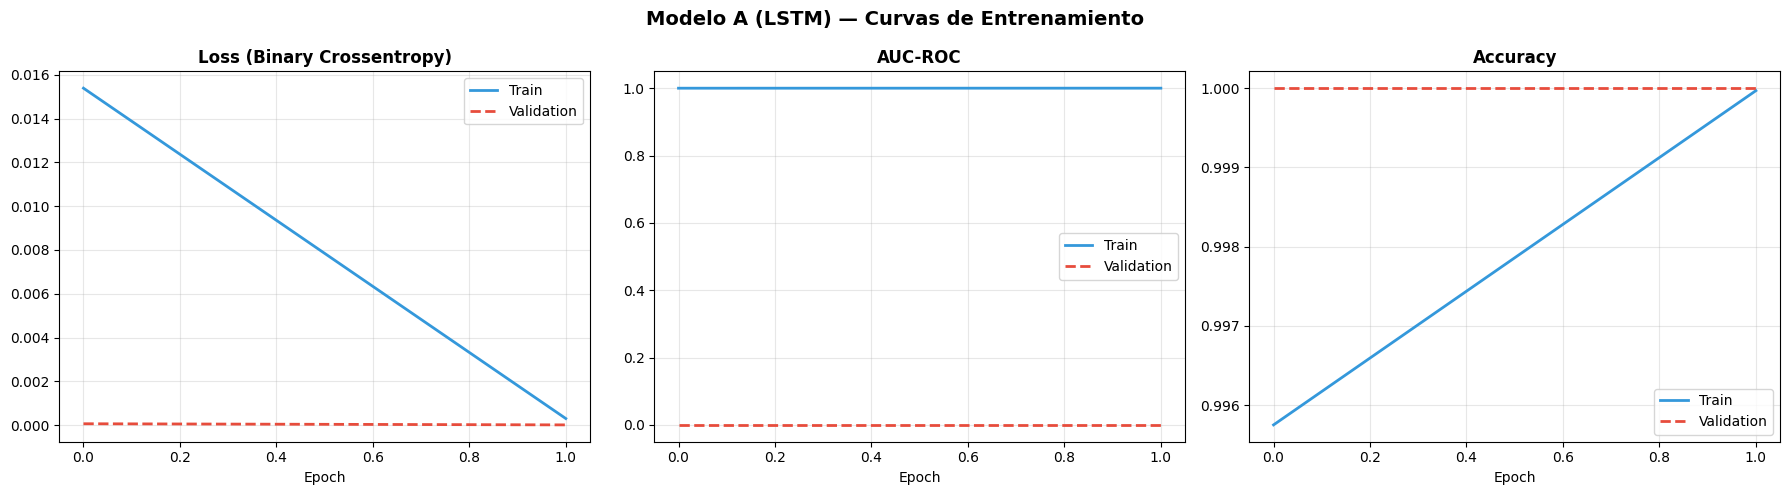

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, metric, title in zip(axes,
    ['loss', 'auc', 'accuracy'],
    ['Loss (Binary Crossentropy)', 'AUC-ROC', 'Accuracy']):
    ax.plot(history.history[metric], label='Train', color='#3498db', linewidth=2)
    ax.plot(history.history[f'val_{metric}'], label='Validation', 
            color='#e74c3c', linestyle='--', linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Modelo A (LSTM) — Curvas de Entrenamiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluación en Test Set

In [13]:
# Predicciones en test
y_prob = model.predict(X_test, verbose=0).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# Diagnóstico rápido
print(f'y_test  — únicos: {np.unique(y_test)}, positivos: {y_test.mean():.2%}')
print(f'y_pred  — únicos: {np.unique(y_pred)}, positivos: {y_pred.mean():.2%}')

# Métricas
try:
    auc = roc_auc_score(y_test, y_prob)
except ValueError:
    auc = float('nan')
f1   = f1_score(y_test, y_pred, zero_division=0)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)

print('=' * 50)
print('📊 MÉTRICAS MODELO A (SSA-LSTM) — TEST SET')
print('=' * 50)
print(f'ROC-AUC:   {auc:.4f}  (objetivo: > 0.85)')
print(f'F1-Score:  {f1:.4f}  (objetivo: > 0.80)')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}  (recall alto = menos alertas perdidas)')
print()
print('Reporte completo:')
print(classification_report(y_test, y_pred, labels=[0,1],
                             target_names=['Normal', 'Alerta Térmica'],
                             zero_division=0))


y_test  — únicos: [1.], positivos: 100.00%
y_pred  — únicos: [1], positivos: 100.00%
📊 MÉTRICAS MODELO A (SSA-LSTM) — TEST SET
ROC-AUC:   nan  (objetivo: > 0.85)
F1-Score:  1.0000  (objetivo: > 0.80)
Precision: 1.0000
Recall:    1.0000  (recall alto = menos alertas perdidas)

Reporte completo:
                precision    recall  f1-score   support

        Normal       0.00      0.00      0.00         0
Alerta Térmica       1.00      1.00      1.00     23796

      accuracy                           1.00     23796
     macro avg       0.50      0.50      0.50     23796
  weighted avg       1.00      1.00      1.00     23796



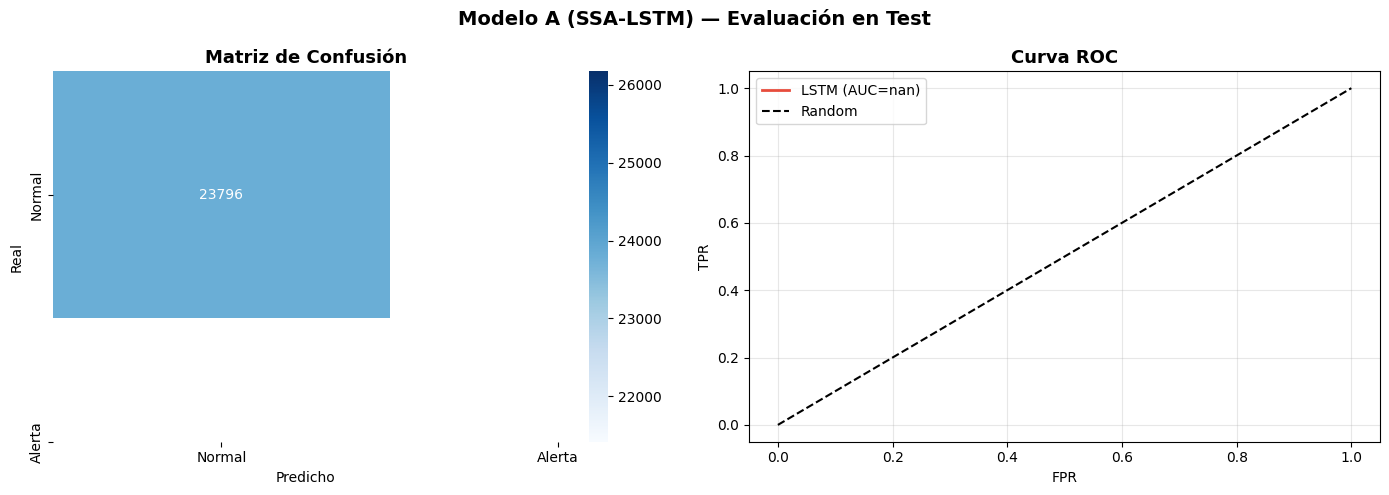

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Alerta'], yticklabels=['Normal', 'Alerta'])
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='#e74c3c', linewidth=2, label=f'LSTM (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', label='Random')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('Curva ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Modelo A (SSA-LSTM) — Evaluación en Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(MODEL_DIR / 'evaluacion_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Guardar Modelo Final

In [15]:
# Guardar modelo en formato .keras (recomendado TF2.x)
model_path = MODEL_DIR / 'lstm_thermal.keras'
model.save(model_path)
print(f'✅ Modelo guardado: {model_path}')

# Verificar que se puede cargar
import tensorflow as tf
model_loaded = tf.keras.models.load_model(model_path)
y_prob_verify = model_loaded.predict(X_test[:5], verbose=0)
print(f'✅ Verificación de carga OK. Predicciones muestra: {y_prob_verify.flatten()}')

# Resumen de artefactos guardados
print('\n📦 Artefactos guardados en', MODEL_DIR)
for f in MODEL_DIR.glob('*'):
    size_mb = f.stat().st_size / 1024 / 1024
    print(f'  {f.name}: {size_mb:.2f} MB')

print('\n🎉 Modelo A (SSA-LSTM) listo para producción!')
print('Consumir desde FastAPI via: app/services/thermal_service.py')

✅ Modelo guardado: artifacts/modelo_A/lstm_thermal.keras
✅ Verificación de carga OK. Predicciones muestra: [0.9999385  0.9999454  0.99994314 0.9999435  0.99994373]

📦 Artefactos guardados en artifacts/modelo_A
  .gitkeep: 0.00 MB
  lstm_thermal.keras: 0.41 MB
  scaler_A.pkl: 0.00 MB
  evaluacion_test.png: 0.08 MB
  curvas_entrenamiento.png: 0.11 MB
  lstm_thermal_best.keras: 0.41 MB
  distribucion_temperatura_tajo.png: 0.08 MB

🎉 Modelo A (SSA-LSTM) listo para producción!
Consumir desde FastAPI via: app/services/thermal_service.py
